In [29]:
import itertools
import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

try:
    import psutil
except ImportError:
    psutil = None


# Config

In [30]:
PROJECT_ROOT = Path("/Users/tun/Documents/2025.2/Machine learning/Project")
ARTIFACT_DIR = PROJECT_ROOT / "data" / "sbert_mpnet_processed"
MODELS_DIR = ARTIFACT_DIR / "models"
RESULTS_DIR = PROJECT_ROOT / "results" / "sbert_mpnet"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDINGS_PATH = ARTIFACT_DIR / "sbert_mpnet_base_v2_embeddings.npz"
CONFIG_PATH = ARTIFACT_DIR / "sbert_config.json"

RANDOM_SEED = 42
N_JOBS = 8
SAVE_MODELS = True
SILHOUETTE_SAMPLE_SIZE = 5000

sns.set_theme(style="whitegrid")
    

# Load

In [31]:
if not EMBEDDINGS_PATH.exists():
    raise FileNotFoundError(
        f"Missing {EMBEDDINGS_PATH}. Run 01_sbert_embedding.ipynb first."
    )

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CONFIG_PATH}. Run 01_sbert_embedding.ipynb first."
    )

arrays = np.load(EMBEDDINGS_PATH)
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

X_train = arrays["X_train"]
X_val = arrays["X_val"]
X_test = arrays["X_test"]
y_train = arrays["y_train"]
y_val = arrays["y_val"]
y_test = arrays["y_test"]
    

In [32]:
id_to_label = {int(key): value for key, value in config["id_to_label"].items()}
label_names = [id_to_label[idx] for idx in sorted(id_to_label)]
num_classes = len(label_names)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Classes:", num_classes)
print(label_names)
    

X_train: (41999, 768)
X_val: (6001, 768)
X_test: (12000, 768)
Classes: 15
['astro-ph', 'cond-mat', 'cs', 'eess', 'gr-qc', 'hep-ex', 'hep-lat', 'hep-ph', 'hep-th', 'math', 'nucl-th', 'physics', 'q-bio', 'quant-ph', 'stat']


# Helpers

In [33]:
def current_memory_mb() -> float:
    if psutil is None:
        return float("nan")
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024**2)


def format_params(params: dict) -> str:
    if not params:
        return "default"
    return ", ".join(f"{key}={value}" for key, value in params.items())
    

In [34]:
def compute_classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def make_result_row(model_name: str, split: str, params: dict, metrics: dict) -> dict:
    row = {
        "model": model_name,
        "split": split,
        "params": format_params(params),
    }
    row.update(metrics)
    return row
    

In [35]:
def fit_estimator(estimator, X_fit: np.ndarray, y_fit: np.ndarray):
    memory_before = current_memory_mb()
    start_time = time.perf_counter()
    estimator.fit(X_fit, y_fit)
    train_time = time.perf_counter() - start_time
    memory_after = current_memory_mb()
    return estimator, train_time, memory_after - memory_before


def predict_with_time(estimator, X_predict: np.ndarray) -> tuple[np.ndarray, float]:
    start_time = time.perf_counter()
    predictions = estimator.predict(X_predict)
    inference_time = time.perf_counter() - start_time
    return predictions, inference_time
    

# Model Plan

Train each required model in its own section while reusing shared helper functions for metrics, timing, tuning, and saving results.

# Results Storage

In [36]:
validation_results = []
test_results = []
best_estimators = {}
test_predictions = {}

print("Models to train:")
for model_name in [
    "GaussianNB",
    "KNN",
    "LogisticRegression",
    "LinearSVC",
    "RandomForest",
    "XGBoost",
    "KMeans",
]:
    print(f"- {model_name}")
    

Models to train:
- GaussianNB
- KNN
- LogisticRegression
- LinearSVC
- RandomForest
- XGBoost
- KMeans


# Training Helpers

In [37]:
def evaluate_on_validation(model_name: str, estimator, params: dict) -> dict:
    val_pred, val_inference_time = predict_with_time(estimator, X_val)
    metrics = compute_classification_metrics(y_val, val_pred)
    row = make_result_row(model_name, "val", params, metrics)
    row["inference_time"] = val_inference_time
    return row


def print_model_result(model_name: str, config_count: int, best_params: dict, best_val_score: float, test_row: dict) -> None:
    print("\n" + "=" * 60)
    print(f"SECTION: {model_name}")
    print("=" * 60)
    print(f"Configs validated : {config_count}")
    print(f"Best params       : {format_params(best_params)}")
    print(f"Validation Macro-F1: {best_val_score:.4f}")
    print(f"Test Accuracy     : {test_row['accuracy']:.4f}")
    print(f"Test Macro-F1     : {test_row['macro_f1']:.4f}")
    print(f"Test Weighted-F1  : {test_row['weighted_f1']:.4f}")
    print(f"Training Time     : {test_row['train_time']:.4f}s")
    print(f"Inference Time    : {test_row['inference_time']:.4f}s")


def tune_retrain_test_classifier(model_name: str, factory, param_grid: list[dict]) -> object:
    best_estimator = None
    best_params = None
    best_score = -1.0
    best_val_inference_time = float("inf")

    for params in param_grid:
        estimator = factory(params)
        estimator, train_time, memory_delta = fit_estimator(estimator, X_train, y_train)
        val_row = evaluate_on_validation(model_name, estimator, params)
        val_row["train_time"] = train_time
        val_row["memory_delta_mb"] = memory_delta
        validation_results.append(val_row)

        is_better_score = val_row["macro_f1"] > best_score
        is_faster_tie = np.isclose(val_row["macro_f1"], best_score, atol=0.002) and val_row["inference_time"] < best_val_inference_time
        if is_better_score or is_faster_tie:
            best_score = val_row["macro_f1"]
            best_val_inference_time = val_row["inference_time"]
            best_estimator = estimator
            best_params = params

    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])

    final_estimator = factory(best_params)
    final_estimator, train_time, memory_delta = fit_estimator(final_estimator, X_train_full, y_train_full)
    test_pred, test_inference_time = predict_with_time(final_estimator, X_test)
    test_metrics = compute_classification_metrics(y_test, test_pred)

    test_row = make_result_row(model_name, "test", best_params, test_metrics)
    test_row.update(
        {
            "train_time": train_time,
            "memory_delta_mb": memory_delta,
            "inference_time": test_inference_time,
        }
    )

    test_results.append(test_row)
    best_estimators[model_name] = final_estimator
    test_predictions[model_name] = test_pred
    print_model_result(model_name, len(param_grid), best_params, best_score, test_row)
    return final_estimator


# Naive Bayes


In [38]:
NB_VAR_SMOOTHING_VALUES = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2]
NB_USE_SCALER = [False, True]

nb_param_grid = [
    {"var_smoothing": var_smoothing, "use_scaler": use_scaler}
    for var_smoothing, use_scaler in itertools.product(
        NB_VAR_SMOOTHING_VALUES,
        NB_USE_SCALER,
    )
]
print(f"GaussianNB configs: {len(nb_param_grid)}")


def create_gaussian_nb(params: dict):
    model_params = dict(params)
    use_scaler = model_params.pop("use_scaler")
    estimator = GaussianNB(**model_params)
    if use_scaler:
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", estimator),
        ])
    return estimator


naive_bayes_model = tune_retrain_test_classifier(
    "GaussianNB",
    create_gaussian_nb,
    nb_param_grid,
)


GaussianNB configs: 14

SECTION: GaussianNB
Configs validated : 14
Best params       : var_smoothing=0.01, use_scaler=False
Validation Macro-F1: 0.8025
Test Accuracy     : 0.8120
Test Macro-F1     : 0.8121
Test Weighted-F1  : 0.8121
Training Time     : 0.0569s
Inference Time    : 0.0863s


# KNN


In [39]:
KNN_NEIGHBORS = [5, 7, 9, 11, 13, 15, 17, 21]
KNN_WEIGHTS = ["distance", "uniform"]
KNN_METRICS = ["cosine"]
KNN_ALGORITHM = "brute"

knn_param_grid = [
    {
        "n_neighbors": n_neighbors,
        "weights": weights,
        "metric": metric,
        "algorithm": KNN_ALGORITHM,
    }
    for n_neighbors, weights, metric in itertools.product(
        KNN_NEIGHBORS,
        KNN_WEIGHTS,
        KNN_METRICS,
    )
]
print(f"KNN configs: {len(knn_param_grid)}")

knn_model = tune_retrain_test_classifier(
    "KNN",
    lambda params: KNeighborsClassifier(n_jobs=N_JOBS, **params),
    knn_param_grid,
)


KNN configs: 16

SECTION: KNN
Configs validated : 16
Best params       : n_neighbors=15, weights=distance, metric=cosine, algorithm=brute
Validation Macro-F1: 0.8603
Test Accuracy     : 0.8683
Test Macro-F1     : 0.8659
Test Weighted-F1  : 0.8659
Training Time     : 0.0093s
Inference Time    : 3.6005s


# Logistic Regression


In [40]:
LOGREG_C_VALUES = [3.0, 5.0, 10.0, 20.0, 30.0, 50.0]
LOGREG_CLASS_WEIGHTS = [None, "balanced"]
LOGREG_USE_SCALER = [False]

logreg_param_grid = [
    {
        "C": c,
        "solver": "lbfgs",
        "class_weight": class_weight,
        "max_iter": 2000,
        "tol": 1e-4,
        "use_scaler": use_scaler,
    }
    for c, class_weight, use_scaler in itertools.product(
        LOGREG_C_VALUES,
        LOGREG_CLASS_WEIGHTS,
        LOGREG_USE_SCALER,
    )
]
print(f"LogisticRegression configs: {len(logreg_param_grid)}")


def create_logistic_regression(params: dict):
    model_params = dict(params)
    use_scaler = model_params.pop("use_scaler")
    estimator = LogisticRegression(random_state=RANDOM_SEED, **model_params)
    if use_scaler:
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", estimator),
        ])
    return estimator


logistic_regression_model = tune_retrain_test_classifier(
    "LogisticRegression",
    create_logistic_regression,
    logreg_param_grid,
)


LogisticRegression configs: 12

SECTION: LogisticRegression
Configs validated : 12
Best params       : C=30.0, solver=lbfgs, class_weight=balanced, max_iter=2000, tol=0.0001, use_scaler=False
Validation Macro-F1: 0.8576
Test Accuracy     : 0.8600
Test Macro-F1     : 0.8600
Test Weighted-F1  : 0.8600
Training Time     : 1.5381s
Inference Time    : 0.0021s


# Linear SVM


In [41]:
svc_param_grid = [
    {
        "C": c,
        "loss": "squared_hinge",
        "dual": False,
        "class_weight": None,
        "tol": 1e-4,
        "max_iter": 5000,
        "use_scaler": False,
    }
    for c in [0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0]
]
print(f"LinearSVC configs: {len(svc_param_grid)}")


def create_linear_svc(params: dict):
    model_params = dict(params)
    use_scaler = model_params.pop("use_scaler")
    estimator = LinearSVC(random_state=RANDOM_SEED, **model_params)
    if use_scaler:
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", estimator),
        ])
    return estimator


svm_model = tune_retrain_test_classifier(
    "LinearSVC",
    create_linear_svc,
    svc_param_grid,
)


LinearSVC configs: 8

SECTION: LinearSVC
Configs validated : 8
Best params       : C=10.0, loss=squared_hinge, dual=False, class_weight=None, tol=0.0001, max_iter=5000, use_scaler=False
Validation Macro-F1: 0.8604
Test Accuracy     : 0.8655
Test Macro-F1     : 0.8648
Test Weighted-F1  : 0.8648
Training Time     : 39.6967s
Inference Time    : 0.0101s


# Random Forest


In [42]:
rf_param_grid = [
    {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "max_features": "sqrt",
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": 2,
        "class_weight": None,
    }
    for n_estimators, max_depth, min_samples_leaf in itertools.product(
        [100, 200, 300],
        [20, 30, None],
        [1, 2],
    )
]
print(f"RandomForest configs: {len(rf_param_grid)}")

random_forest_model = tune_retrain_test_classifier(
    "RandomForest",
    lambda params: RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=N_JOBS, **params),
    rf_param_grid,
)


RandomForest configs: 18

SECTION: RandomForest
Configs validated : 18
Best params       : n_estimators=200, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, class_weight=None
Validation Macro-F1: 0.8411
Test Accuracy     : 0.8452
Test Macro-F1     : 0.8433
Test Weighted-F1  : 0.8433
Training Time     : 21.4223s
Inference Time    : 0.0772s


# XGBoost


In [43]:
try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise RuntimeError(
        "XGBoost cannot be loaded. Install it with `pip install xgboost`. "
        "On macOS, if libomp is missing after installation, run `brew install libomp`, "
        "then restart the notebook kernel and run again."
    ) from exc

xgb_param_grid = [
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0, "reg_alpha": 0.0, "min_child_weight": 1},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0, "reg_alpha": 0.0, "min_child_weight": 1},
    {"n_estimators": 400, "max_depth": 5, "learning_rate": 0.05, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0, "reg_alpha": 0.0, "min_child_weight": 1},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0, "reg_alpha": 0.0, "min_child_weight": 1},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0, "reg_alpha": 0.0, "min_child_weight": 1},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.1, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 3.0, "reg_alpha": 0.0, "min_child_weight": 1},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0, "reg_alpha": 0.0, "min_child_weight": 1},
    {"n_estimators": 400, "max_depth": 3, "learning_rate": 0.1, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 3.0, "reg_alpha": 0.0, "min_child_weight": 1},
]
print(f"XGBoost configs: {len(xgb_param_grid)}")

xgboost_model = tune_retrain_test_classifier(
    "XGBoost",
    lambda params: XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=N_JOBS,
        verbosity=0,
        **params,
    ),
    xgb_param_grid,
)


XGBoost configs: 8

SECTION: XGBoost
Configs validated : 8
Best params       : n_estimators=300, max_depth=5, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, reg_lambda=3.0, reg_alpha=0.0, min_child_weight=1
Validation Macro-F1: 0.8582
Test Accuracy     : 0.8608
Test Macro-F1     : 0.8610
Test Weighted-F1  : 0.8610
Training Time     : 95.4166s
Inference Time    : 0.0529s


# KMeans


In [44]:
def map_clusters_to_labels(cluster_ids: np.ndarray, true_labels: np.ndarray) -> dict[int, int]:
    matrix = confusion_matrix(true_labels, cluster_ids, labels=range(num_classes))
    label_indices, cluster_indices = linear_sum_assignment(-matrix)
    return {int(cluster): int(label) for label, cluster in zip(label_indices, cluster_indices)}


def apply_cluster_mapping(cluster_ids: np.ndarray, mapping: dict[int, int]) -> np.ndarray:
    return np.array([mapping.get(int(cluster), -1) for cluster in cluster_ids])


kmeans_param_grid = [
    {"n_clusters": num_classes, "init": "k-means++", "n_init": n_init}
    for n_init in [10, 30, 50]
]
print(f"KMeans configs: {len(kmeans_param_grid)}")

kmeans_best_estimator = None
kmeans_best_mapping = None
kmeans_best_params = None
kmeans_best_score = -1.0
kmeans_best_val_inference_time = float("inf")

for params in kmeans_param_grid:
    estimator = KMeans(random_state=RANDOM_SEED, **params)

    memory_before = current_memory_mb()
    start_time = time.perf_counter()
    train_clusters = estimator.fit_predict(X_train)
    train_time = time.perf_counter() - start_time
    memory_delta = current_memory_mb() - memory_before

    cluster_to_label = map_clusters_to_labels(train_clusters, y_train)
    val_clusters, val_inference_time = predict_with_time(estimator, X_val)
    val_pred = apply_cluster_mapping(val_clusters, cluster_to_label)

    val_metrics = compute_classification_metrics(y_val, val_pred)
    val_metrics["adjusted_rand_index"] = adjusted_rand_score(y_val, val_clusters)
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(X_val))
    val_metrics["silhouette_score"] = silhouette_score(
        X_val,
        val_clusters,
        sample_size=sample_size,
        random_state=RANDOM_SEED,
    )

    val_row = make_result_row("KMeans", "val", params, val_metrics)
    val_row["train_time"] = train_time
    val_row["memory_delta_mb"] = memory_delta
    val_row["inference_time"] = val_inference_time
    validation_results.append(val_row)

    is_better_score = val_row["macro_f1"] > kmeans_best_score
    is_faster_tie = np.isclose(val_row["macro_f1"], kmeans_best_score, atol=0.002) and val_inference_time < kmeans_best_val_inference_time
    if is_better_score or is_faster_tie:
        kmeans_best_score = val_row["macro_f1"]
        kmeans_best_val_inference_time = val_inference_time
        kmeans_best_estimator = estimator
        kmeans_best_mapping = cluster_to_label
        kmeans_best_params = params

X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

kmeans_model = KMeans(random_state=RANDOM_SEED, **kmeans_best_params)
memory_before = current_memory_mb()
start_time = time.perf_counter()
train_full_clusters = kmeans_model.fit_predict(X_train_full)
kmeans_train_time = time.perf_counter() - start_time
kmeans_memory_delta = current_memory_mb() - memory_before
kmeans_cluster_to_label = map_clusters_to_labels(train_full_clusters, y_train_full)

test_clusters, kmeans_test_inference_time = predict_with_time(kmeans_model, X_test)
y_test_kmeans = apply_cluster_mapping(test_clusters, kmeans_cluster_to_label)
kmeans_test_metrics = compute_classification_metrics(y_test, y_test_kmeans)
kmeans_test_metrics["adjusted_rand_index"] = adjusted_rand_score(y_test, test_clusters)
sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(X_test))
kmeans_test_metrics["silhouette_score"] = silhouette_score(
    X_test,
    test_clusters,
    sample_size=sample_size,
    random_state=RANDOM_SEED,
)

kmeans_row = make_result_row("KMeans", "test", kmeans_best_params, kmeans_test_metrics)
kmeans_row.update(
    {
        "train_time": kmeans_train_time,
        "memory_delta_mb": kmeans_memory_delta,
        "inference_time": kmeans_test_inference_time,
    }
)

test_results.append(kmeans_row)
best_estimators["KMeans"] = kmeans_model
test_predictions["KMeans"] = y_test_kmeans
print_model_result("KMeans", len(kmeans_param_grid), kmeans_best_params, kmeans_best_score, kmeans_row)


KMeans configs: 3

SECTION: KMeans
Configs validated : 3
Best params       : n_clusters=15, init=k-means++, n_init=50
Validation Macro-F1: 0.6690
Test Accuracy     : 0.6775
Test Macro-F1     : 0.6679
Test Weighted-F1  : 0.6679
Training Time     : 27.5052s
Inference Time    : 0.0097s


# Summary Of All Models


In [45]:
validation_df = pd.DataFrame(validation_results)
test_df = pd.DataFrame(test_results).sort_values("macro_f1", ascending=False).reset_index(drop=True)

summary_columns = [
    "model",
    "params",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "precision_macro",
    "recall_macro",
    "train_time",
    "inference_time",
]

pd.set_option("display.max_colwidth", 120)
print("\n" + "=" * 60)
print("SUMMARY OF ALL MODELS")
print("=" * 60)
display(test_df[summary_columns])



SUMMARY OF ALL MODELS


,model,params,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,train_time,inference_time
0,KNN,"n_neighbors=15, weights=distance, metric=cosine, algorithm=brute",0.868333,0.865853,0.865853,0.869488,0.868333,0.009286,3.600494
1,LinearSVC,"C=10.0, loss=squared_hinge, dual=False, class_weight=None, tol=0.0001, max_iter=5000, use_scaler=False",0.865500,0.864825,0.864825,0.864748,0.865500,39.696736,0.010148
2,XGBoost,"n_estimators=300, max_depth=5, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, reg_lambda=3.0, reg_alpha=0.0...",0.860750,0.861009,0.861009,0.861548,0.860750,95.416566,0.052900
3,LogisticRegression,"C=30.0, solver=lbfgs, class_weight=balanced, max_iter=2000, tol=0.0001, use_scaler=False",0.860000,0.859967,0.859967,0.860118,0.860000,1.538105,0.002104
4,RandomForest,"n_estimators=200, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, class_weight=None",0.845167,0.843325,0.843325,0.843794,0.845167,21.422314,0.077176
5,GaussianNB,"var_smoothing=0.01, use_scaler=False",0.812000,0.812055,0.812055,0.813767,0.812000,0.056949,0.086329
6,KMeans,"n_clusters=15, init=k-means++, n_init=50",0.677500,0.667886,0.667886,0.678579,0.677500,27.505233,0.009659


In [46]:
best_model_name = test_df.iloc[0]["model"]
best_prediction = test_predictions[best_model_name]

print(f"Best model by Macro-F1: {best_model_name}")
print(
    classification_report(
        y_test,
        best_prediction,
        target_names=label_names,
        zero_division=0,
    )
)


Best model by Macro-F1: KNN
              precision    recall  f1-score   support

    astro-ph       0.96      0.93      0.95       800
    cond-mat       0.85      0.88      0.86       800
          cs       0.89      0.85      0.87       800
        eess       0.85      0.87      0.86       800
       gr-qc       0.82      0.93      0.87       800
      hep-ex       0.80      0.96      0.87       800
     hep-lat       0.87      0.95      0.91       800
      hep-ph       0.86      0.66      0.75       800
      hep-th       0.88      0.80      0.84       800
        math       0.94      0.89      0.91       800
     nucl-th       0.87      0.91      0.89       800
     physics       0.82      0.63      0.71       800
       q-bio       0.87      0.94      0.90       800
    quant-ph       0.87      0.93      0.90       800
        stat       0.88      0.90      0.89       800

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     1200

# Visualization


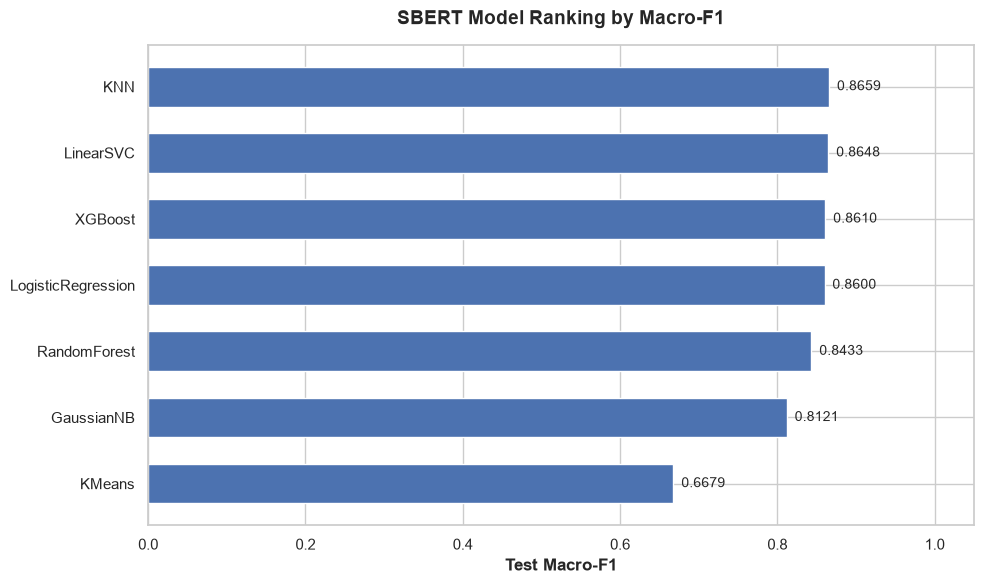

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/model_comparison_macro_f1.png


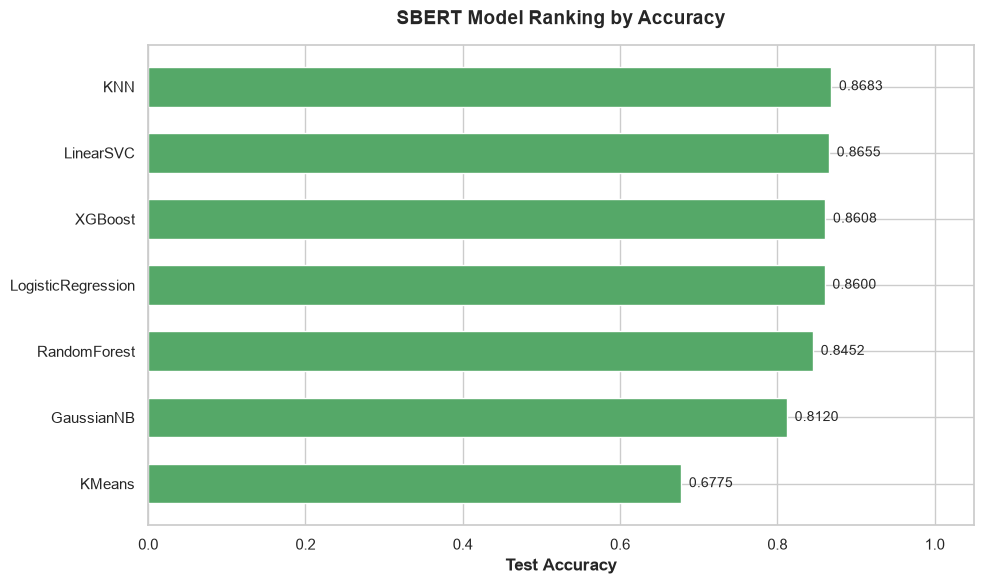

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/model_comparison_accuracy.png


In [47]:
# Chart 1: Macro-F1 ranking
plt.figure(figsize=(10, 6))
plot_df = test_df.sort_values("macro_f1", ascending=True)
bars = plt.barh(plot_df["model"], plot_df["macro_f1"], color="#4C72B0", edgecolor="white", height=0.6)
plt.xlabel("Test Macro-F1", fontsize=12, fontweight="bold")
plt.title("SBERT Model Ranking by Macro-F1", fontsize=14, fontweight="bold", pad=15)
plt.xlim(0, 1.05)
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.4f}", va="center", fontsize=10)
plt.tight_layout()
macro_f1_path = RESULTS_DIR / "model_comparison_macro_f1.png"
plt.savefig(macro_f1_path, dpi=160)
plt.show()
print(f"Saved: {macro_f1_path}")

# Chart 2: Accuracy ranking
plt.figure(figsize=(10, 6))
plot_df = test_df.sort_values("accuracy", ascending=True)
bars = plt.barh(plot_df["model"], plot_df["accuracy"], color="#55A868", edgecolor="white", height=0.6)
plt.xlabel("Test Accuracy", fontsize=12, fontweight="bold")
plt.title("SBERT Model Ranking by Accuracy", fontsize=14, fontweight="bold", pad=15)
plt.xlim(0, 1.05)
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.4f}", va="center", fontsize=10)
plt.tight_layout()
accuracy_path = RESULTS_DIR / "model_comparison_accuracy.png"
plt.savefig(accuracy_path, dpi=160)
plt.show()
print(f"Saved: {accuracy_path}")


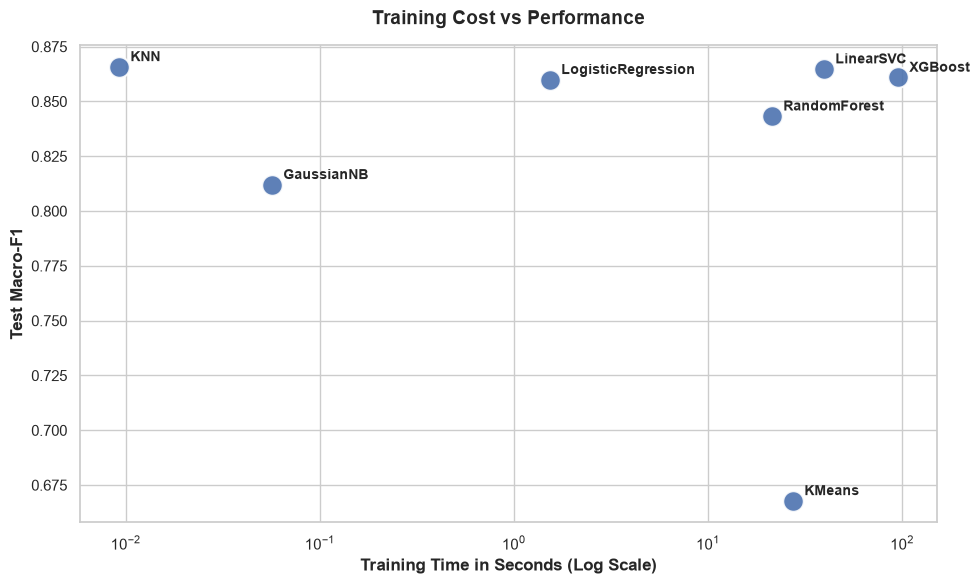

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/model_comparison_time.png


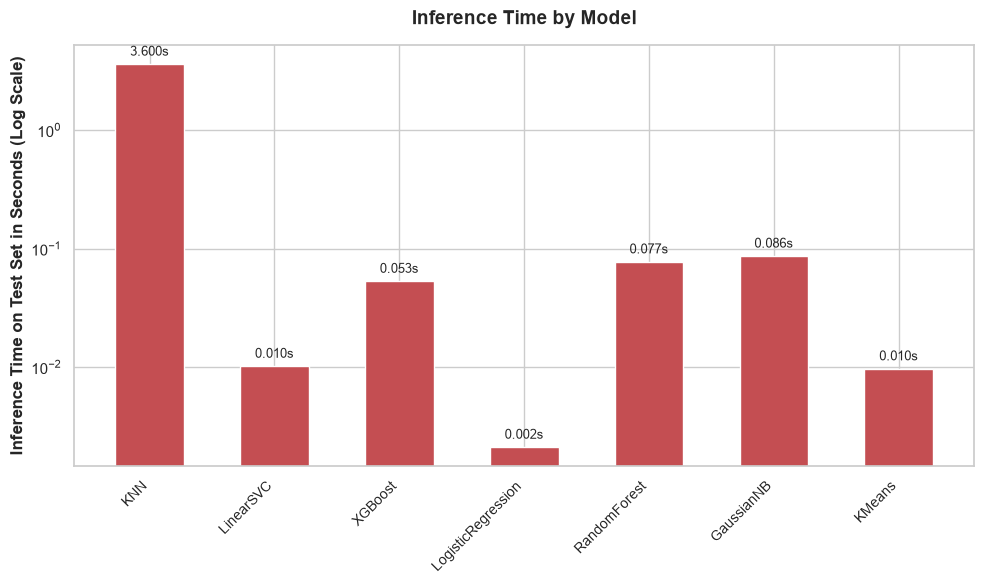

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/model_comparison_inference_time.png


In [48]:
# Chart 3: Training cost vs performance
plt.figure(figsize=(10, 6))
plt.scatter(test_df["train_time"], test_df["macro_f1"], color="#4C72B0", s=220, edgecolor="white", linewidth=1.5, alpha=0.9)
for _, row in test_df.iterrows():
    plt.annotate(row["model"], (row["train_time"], row["macro_f1"]), xytext=(8, 4), textcoords="offset points", fontsize=10, fontweight="bold")
plt.xscale("log")
plt.xlabel("Training Time in Seconds (Log Scale)", fontsize=12, fontweight="bold")
plt.ylabel("Test Macro-F1", fontsize=12, fontweight="bold")
plt.title("Training Cost vs Performance", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
cost_path = RESULTS_DIR / "model_comparison_time.png"
plt.savefig(cost_path, dpi=160)
plt.show()
print(f"Saved: {cost_path}")

# Chart 4: Inference time
plt.figure(figsize=(10, 6))
bars = plt.bar(test_df["model"], test_df["inference_time"], color="#C44E52", edgecolor="white", width=0.55)
plt.yscale("log")
plt.ylabel("Inference Time on Test Set in Seconds (Log Scale)", fontsize=12, fontweight="bold")
plt.title("Inference Time by Model", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval * 1.12, f"{yval:.3f}s", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
inference_path = RESULTS_DIR / "model_comparison_inference_time.png"
plt.savefig(inference_path, dpi=160)
plt.show()
print(f"Saved: {inference_path}")


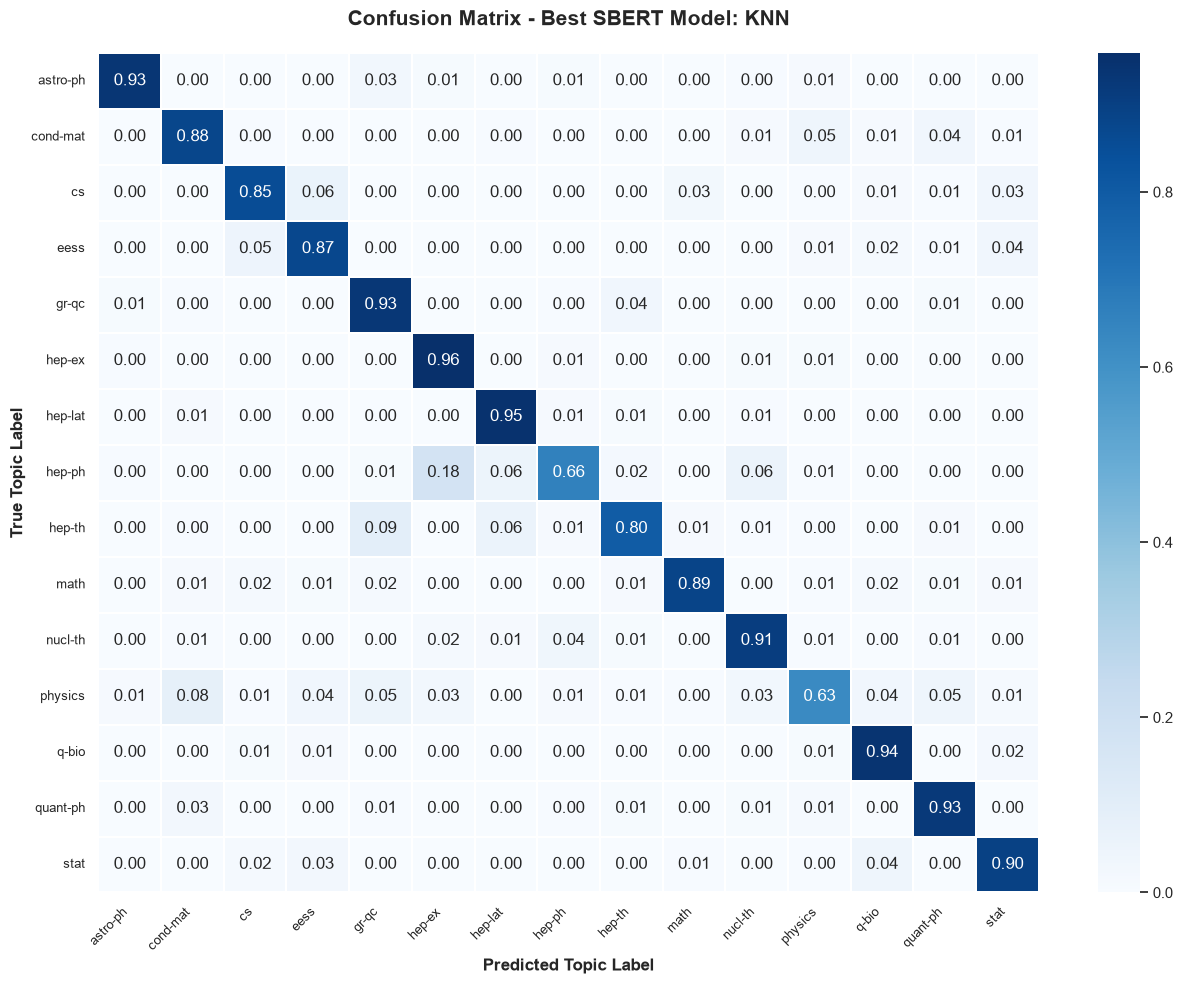

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/confusion_matrix_best_model.png


In [49]:
# Chart 5: Confusion matrix for best model
conf_matrix = confusion_matrix(y_test, best_prediction, labels=range(num_classes))
conf_matrix_normalized = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(13, 10))
sns.heatmap(
    conf_matrix_normalized,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    xticklabels=label_names,
    yticklabels=label_names,
    linewidths=0.3,
)
plt.title(f"Confusion Matrix - Best SBERT Model: {best_model_name}", fontsize=15, fontweight="bold", pad=20)
plt.xlabel("Predicted Topic Label", fontsize=12, fontweight="bold")
plt.ylabel("True Topic Label", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
confusion_path = RESULTS_DIR / "confusion_matrix_best_model.png"
plt.savefig(confusion_path, dpi=160)
plt.show()
print(f"Saved: {confusion_path}")


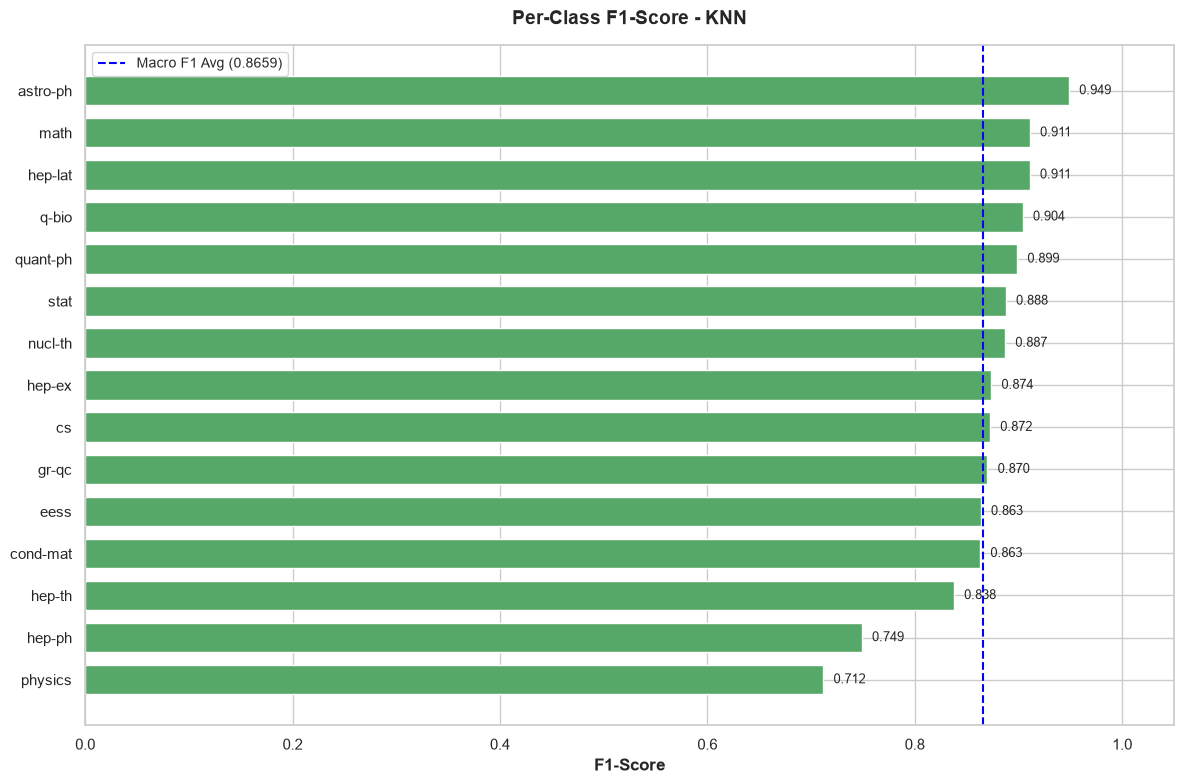

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/per_class_f1_best_model.png


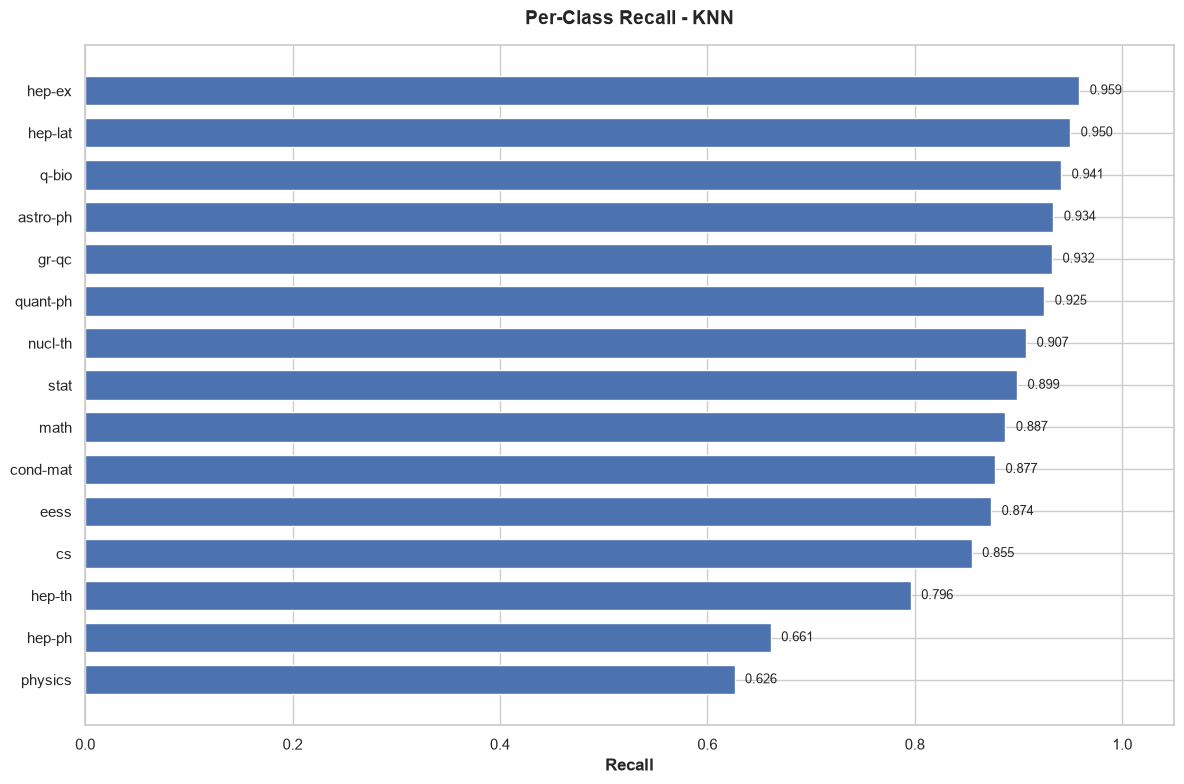

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/per_class_recall_best_model.png


In [50]:
# Chart 6: Per-class F1 and recall for best model
report_dict = classification_report(
    y_test,
    best_prediction,
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)

per_class_df = pd.DataFrame(
    {
        "label": label_names,
        "f1_score": [report_dict[label]["f1-score"] for label in label_names],
        "recall": [report_dict[label]["recall"] for label in label_names],
    }
).sort_values("f1_score", ascending=True)

plt.figure(figsize=(12, 8))
bars = plt.barh(per_class_df["label"], per_class_df["f1_score"], color="#55A868", edgecolor="white", height=0.7)
plt.xlabel("F1-Score", fontsize=12, fontweight="bold")
plt.title(f"Per-Class F1-Score - {best_model_name}", fontsize=14, fontweight="bold", pad=15)
plt.xlim(0, 1.05)
macro_avg = report_dict["macro avg"]["f1-score"]
plt.axvline(x=macro_avg, color="blue", linestyle="--", label=f"Macro F1 Avg ({macro_avg:.4f})")
plt.legend(fontsize=10)
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.3f}", va="center", fontsize=9)
plt.tight_layout()
per_class_f1_path = RESULTS_DIR / "per_class_f1_best_model.png"
plt.savefig(per_class_f1_path, dpi=160)
plt.show()
print(f"Saved: {per_class_f1_path}")

plt.figure(figsize=(12, 8))
recall_df = per_class_df.sort_values("recall", ascending=True)
bars = plt.barh(recall_df["label"], recall_df["recall"], color="#4C72B0", edgecolor="white", height=0.7)
plt.xlabel("Recall", fontsize=12, fontweight="bold")
plt.title(f"Per-Class Recall - {best_model_name}", fontsize=14, fontweight="bold", pad=15)
plt.xlim(0, 1.05)
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.3f}", va="center", fontsize=9)
plt.tight_layout()
per_class_recall_path = RESULTS_DIR / "per_class_recall_best_model.png"
plt.savefig(per_class_recall_path, dpi=160)
plt.show()
print(f"Saved: {per_class_recall_path}")


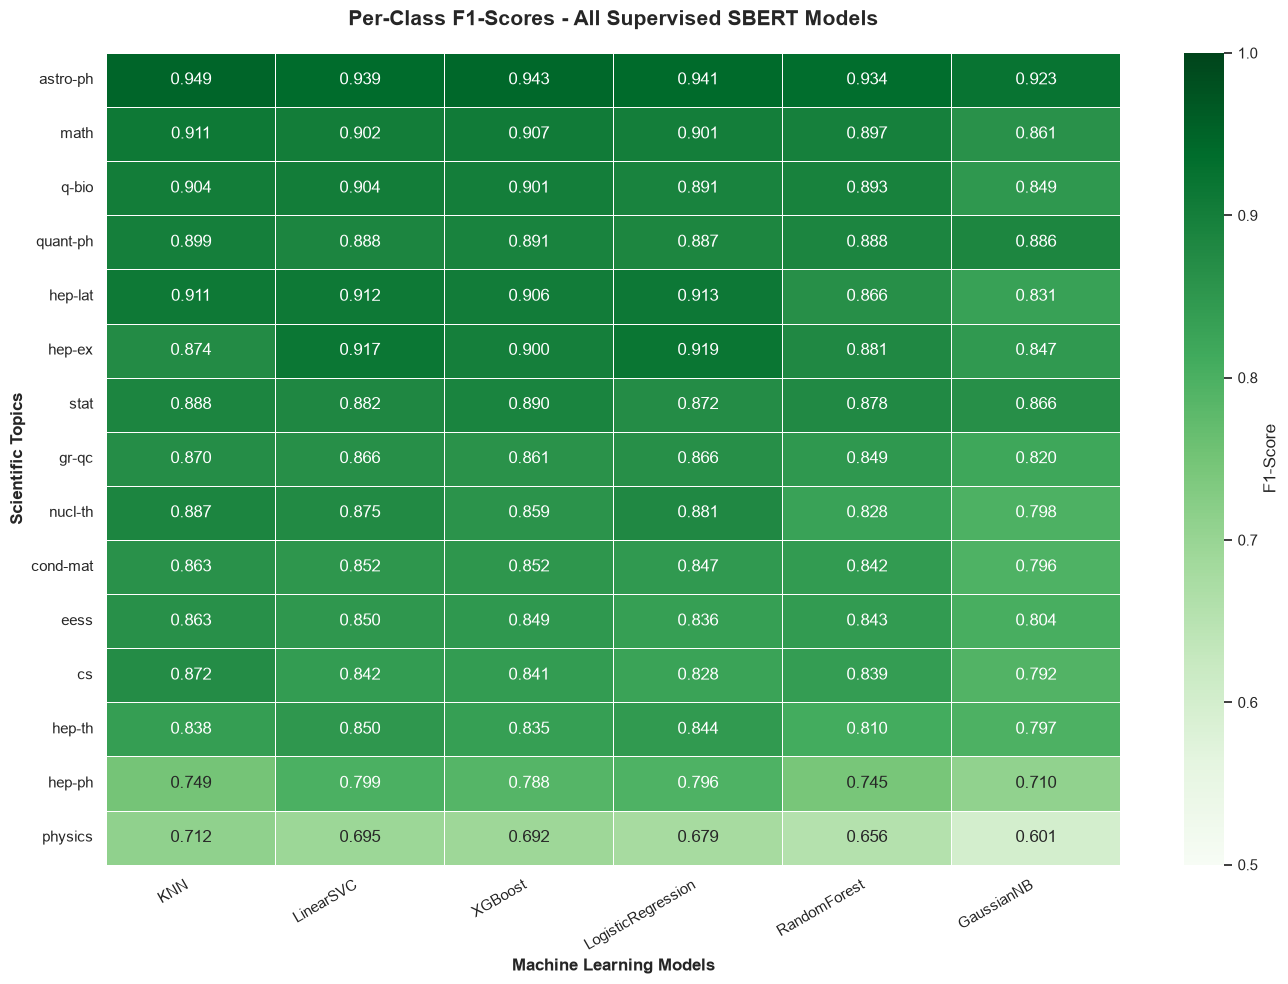

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/per_class_f1_all_supervised_models.png


In [51]:
# Chart 7: Per-class F1 heatmap for all supervised models
supervised_models = [
    model_name
    for model_name in test_df["model"].tolist()
    if model_name != "KMeans" and model_name in test_predictions
]

f1_data = {}
for model_name in supervised_models:
    report = classification_report(
        y_test,
        test_predictions[model_name],
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    f1_data[model_name] = [report[label]["f1-score"] for label in label_names]

f1_heatmap_df = pd.DataFrame(f1_data, index=label_names)
f1_heatmap_df["Average"] = f1_heatmap_df.mean(axis=1)
f1_heatmap_df = f1_heatmap_df.sort_values("Average", ascending=False).drop(columns=["Average"])

plt.figure(figsize=(14, 10))
sns.heatmap(
    f1_heatmap_df,
    annot=True,
    cmap="Greens",
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "F1-Score"},
    vmin=0.5,
    vmax=1.0,
)
plt.title("Per-Class F1-Scores - All Supervised SBERT Models", fontsize=15, fontweight="bold", pad=20)
plt.ylabel("Scientific Topics", fontsize=12, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12, fontweight="bold")
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
per_class_f1_heatmap_path = RESULTS_DIR / "per_class_f1_all_supervised_models.png"
plt.savefig(per_class_f1_heatmap_path, dpi=160)
plt.show()
print(f"Saved: {per_class_f1_heatmap_path}")


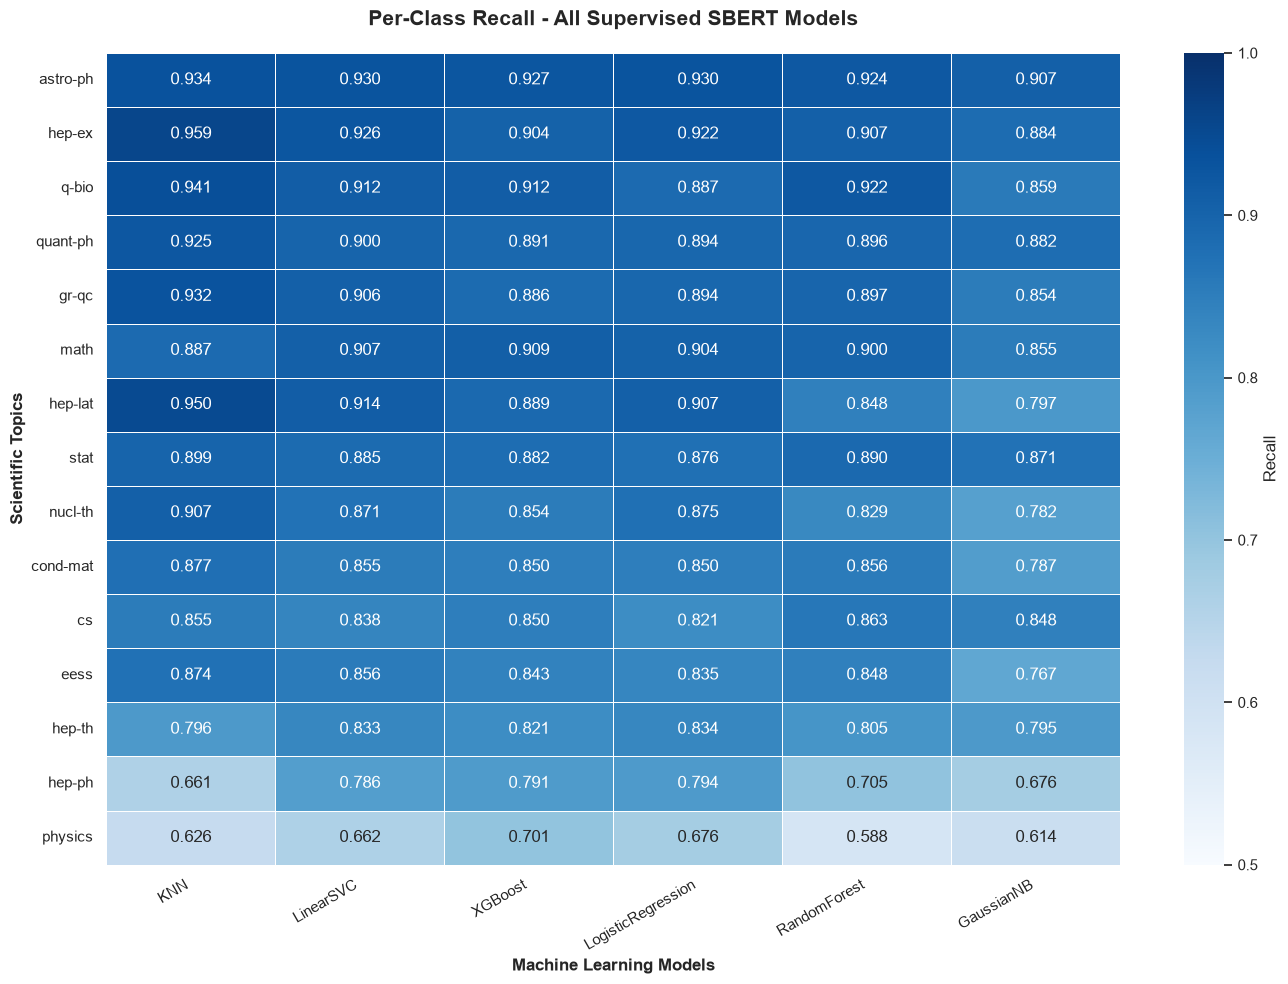

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/per_class_recall_all_supervised_models.png


In [52]:
# Chart 8: Per-class recall heatmap for all supervised models
recall_data = {}
for model_name in supervised_models:
    report = classification_report(
        y_test,
        test_predictions[model_name],
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    recall_data[model_name] = [report[label]["recall"] for label in label_names]

recall_heatmap_df = pd.DataFrame(recall_data, index=label_names)
recall_heatmap_df["Average"] = recall_heatmap_df.mean(axis=1)
recall_heatmap_df = recall_heatmap_df.sort_values("Average", ascending=False).drop(columns=["Average"])

plt.figure(figsize=(14, 10))
sns.heatmap(
    recall_heatmap_df,
    annot=True,
    cmap="Blues",
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Recall"},
    vmin=0.5,
    vmax=1.0,
)
plt.title("Per-Class Recall - All Supervised SBERT Models", fontsize=15, fontweight="bold", pad=20)
plt.ylabel("Scientific Topics", fontsize=12, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12, fontweight="bold")
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
per_class_recall_heatmap_path = RESULTS_DIR / "per_class_recall_all_supervised_models.png"
plt.savefig(per_class_recall_heatmap_path, dpi=160)
plt.show()
print(f"Saved: {per_class_recall_heatmap_path}")


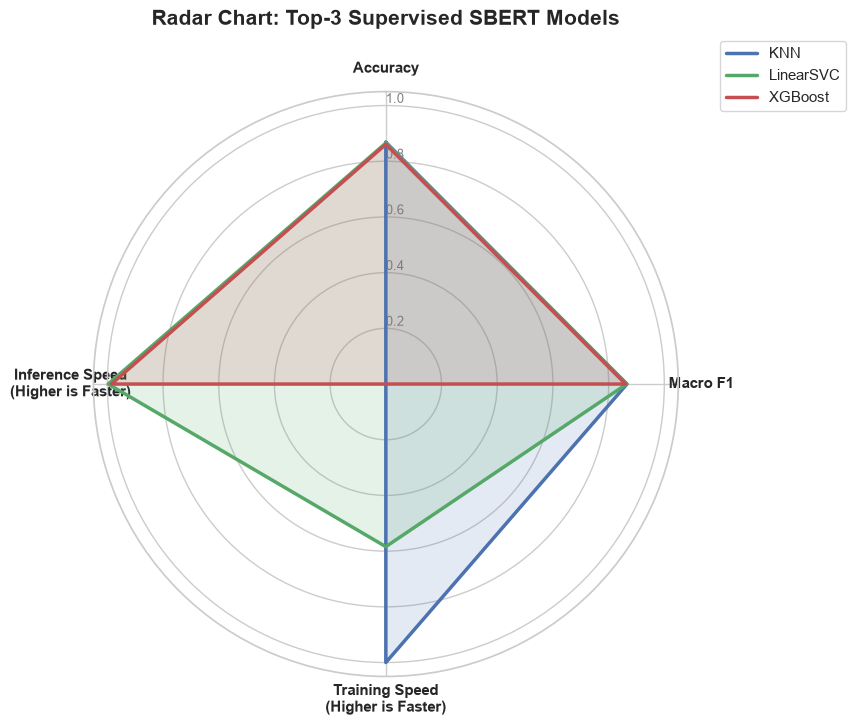

Saved: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet/radar_top3_supervised_models.png


In [53]:
# Chart 9: Radar chart for top 3 supervised models by Macro-F1
from math import pi

top3_df = (
    test_df[test_df["model"].isin(supervised_models)]
    .sort_values("macro_f1", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

max_train_time = top3_df["train_time"].max()
max_inference_time = top3_df["inference_time"].max()

radar_metrics = [
    "Accuracy",
    "Macro F1",
    "Training Speed\n(Higher is Faster)",
    "Inference Speed\n(Higher is Faster)",
]
num_metrics = len(radar_metrics)
angles = [idx / float(num_metrics) * 2 * pi for idx in range(num_metrics)]
angles += angles[:1]

plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], radar_metrics, fontsize=11, fontweight="bold")
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=9)
plt.ylim(0, 1.05)

radar_colors = ["#4C72B0", "#55A868", "#C44E52"]
for idx, row in top3_df.iterrows():
    train_speed = (max_train_time - row["train_time"]) / max_train_time if max_train_time > 0 else 1.0
    inference_speed = (max_inference_time - row["inference_time"]) / max_inference_time if max_inference_time > 0 else 1.0
    values = [
        row["accuracy"],
        row["macro_f1"],
        train_speed,
        inference_speed,
    ]
    values += values[:1]
    ax.plot(angles, values, color=radar_colors[idx], linewidth=2.5, linestyle="solid", label=row["model"])
    ax.fill(angles, values, color=radar_colors[idx], alpha=0.15)

plt.title("Radar Chart: Top-3 Supervised SBERT Models", size=15, fontweight="bold", y=1.1)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
radar_path = RESULTS_DIR / "radar_top3_supervised_models.png"
plt.savefig(radar_path, dpi=160)
plt.show()
print(f"Saved: {radar_path}")


# Save


In [54]:
metrics_csv_path = ARTIFACT_DIR / "sbert_model_metrics.csv"
metrics_json_path = ARTIFACT_DIR / "sbert_model_metrics.json"
validation_csv_path = ARTIFACT_DIR / "sbert_validation_metrics.csv"

test_df.to_csv(metrics_csv_path, index=False)
test_df.to_json(metrics_json_path, orient="records", indent=2)
validation_df.to_csv(validation_csv_path, index=False)

print(f"Saved: {metrics_csv_path}")
print(f"Saved: {metrics_json_path}")
print(f"Saved: {validation_csv_path}")


Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/sbert_model_metrics.csv
Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/sbert_model_metrics.json
Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/sbert_validation_metrics.csv


In [55]:
if SAVE_MODELS:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    for model_name, estimator in best_estimators.items():
        model_path = MODELS_DIR / f"{model_name.lower()}_model.joblib"
        joblib.dump(estimator, model_path)
        print(f"Saved: {model_path}")
else:
    print("Model saving skipped. Set SAVE_MODELS = True to save final estimators.")


Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/models/gaussiannb_model.joblib
Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/models/knn_model.joblib
Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/models/logisticregression_model.joblib
Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/models/linearsvc_model.joblib
Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/models/randomforest_model.joblib
Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/models/xgboost_model.joblib
Saved: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed/models/kmeans_model.joblib


# Notes


In [56]:
print("Done.")
print(f"Best model: {best_model_name}")
print(f"Artifacts saved in: {ARTIFACT_DIR}")
print(f"Figures saved in: {RESULTS_DIR}")


Done.
Best model: KNN
Artifacts saved in: /Users/tun/Documents/2025.2/Machine learning/Project/data/sbert_mpnet_processed
Figures saved in: /Users/tun/Documents/2025.2/Machine learning/Project/results/sbert_mpnet
